max borrow ratio 3.333333333333334


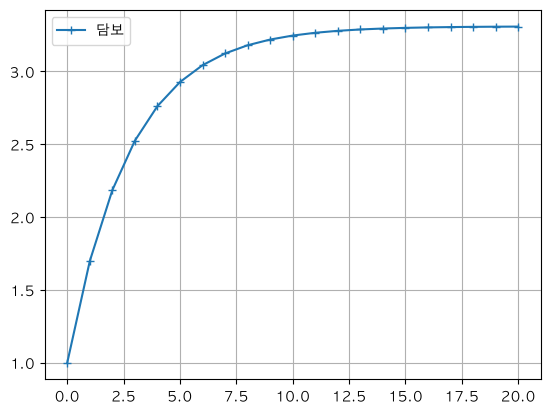

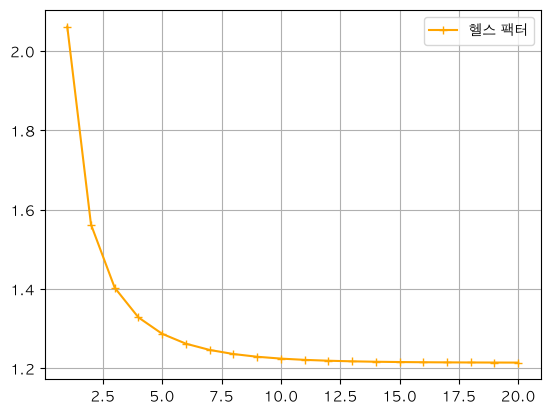

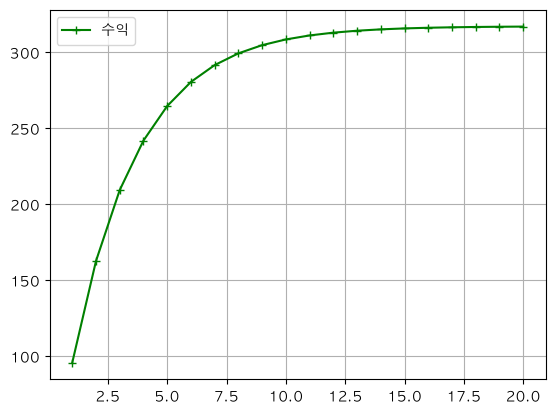

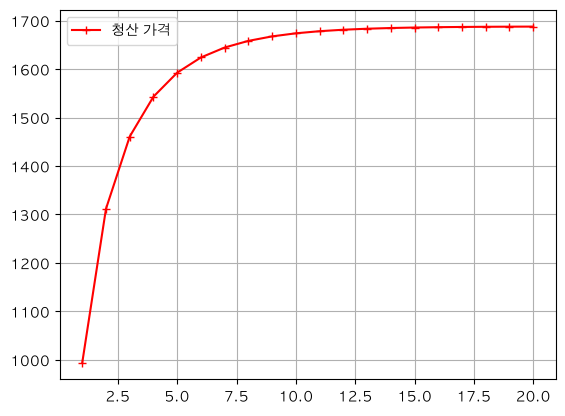

In [18]:
# 레버리지 - ETH를 담보로 맡기고 DAI 차입
col_amt = 1
col_usd_price = 2000
col_usd = col_amt * col_usd_price

liq_threshold = 0.85
ltv = 0.8
ltv_buffer = 0.1
assert liq_threshold >= ltv >= ltv_buffer >= 0

# 최대 차입 비율 - 등비급수
max_borrow_ratio = 1 / (1 - (ltv - ltv_buffer))
print("max borrow ratio", max_borrow_ratio)

# 예치 이자율
r_s = 0
# 차입 이자율
r_b = 0.10
Y = 365

swap_fee = 0.003

borrow_usd_price = 1

## 레버리지 ##
plot_data = {
    "total_col_amt": [col_amt],
    "total_borrow_amt": [0],
    "hf": [None],
    "profit": [None],
    "liq_price": [None]
}
total_col_amt = col_amt
total_borrow_amt = 0

# 차입에 사용할 수 있는 담보
col_free = col_amt
for i in range(20):
    borrow_usd = (ltv - ltv_buffer) * col_free * col_usd_price
    borrow_amt = borrow_usd / borrow_usd_price

    # 스왑 가격이 일정하다고 가정
    col_free = borrow_usd / col_usd_price * (1 - swap_fee)

    total_borrow_amt += borrow_amt
    total_col_amt += col_free
    hf = liq_threshold * total_col_amt * col_usd_price / (total_borrow_amt * borrow_usd_price)

    # 수익 계산
    # 단순화를 위한 가정
    # - 가스비 없음
    # - 스왑 가격은 일정
    # - 전체 담보에서 최초 담보를 뺀 만큼 스왑
    # - 예치 이자 없음
    # - 차입 자산 가격은 변하지 않음
    dt = 90
    delta_col_usd_price = 0.1
    repay_amt = total_borrow_amt * (1 + r_b/Y)**dt
    repay_usd = repay_amt * borrow_usd_price
    profit = (total_col_amt - col_amt) * (1 - swap_fee) * (1 + delta_col_usd_price) * col_usd_price - repay_usd

    # 청산 가격
    # 청산 = hf <= 1
    # hf = liq_threshold * total_col_usd / repay_usd <= 1
    # 청산 시 담보 가격 <= total_borro_usd / (liq_threshold * total_col_amt)
    liq_price = repay_usd / (liq_threshold * total_col_amt)

    plot_data["total_borrow_amt"].append(total_borrow_amt)
    plot_data["total_col_amt"].append(total_col_amt)
    plot_data["hf"].append(hf)
    plot_data["profit"].append(profit)
    plot_data["liq_price"].append(liq_price)

### 그래프 ###
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

plt.plot(plot_data["total_col_amt"], marker = "+")
plt.legend(["담보"])
plt.grid()
plt.show()

plt.plot(plot_data["hf"], marker = "+", color = "orange")
plt.legend(["헬스 팩터"])
plt.grid()
plt.show()

plt.plot(plot_data["profit"], marker = "+", color = "green")
plt.legend(["수익"])
plt.grid()
plt.show()

plt.plot(plot_data["liq_price"], marker = "+", color = "red")
plt.legend(["청산 가격"])
plt.grid()
plt.show()

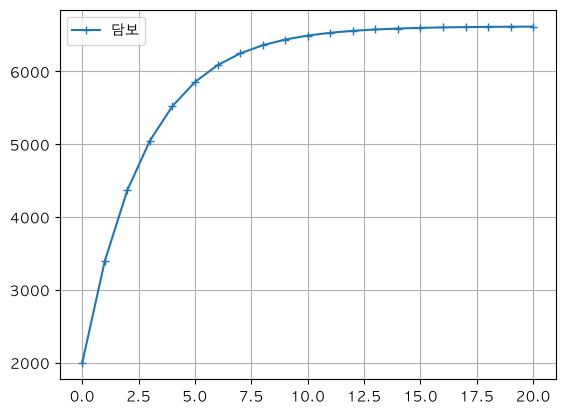

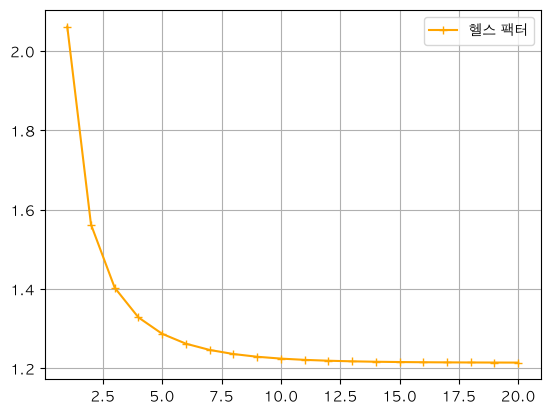

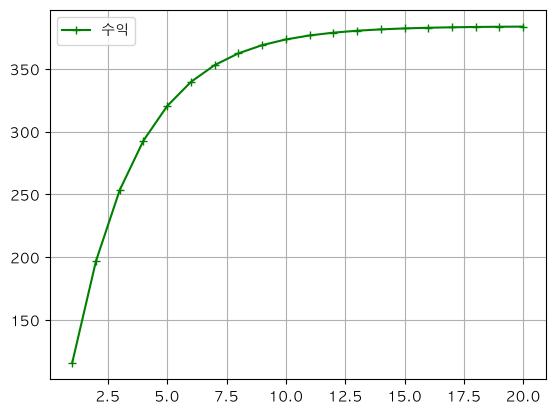

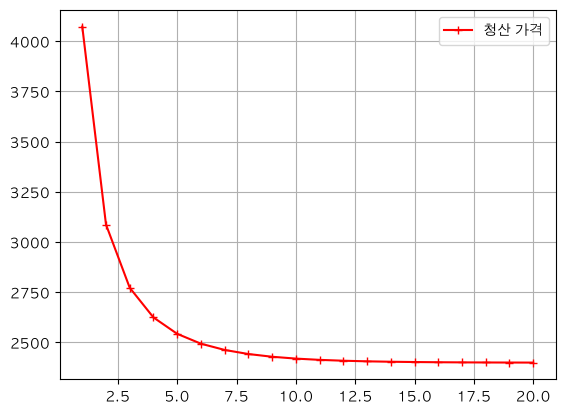

In [19]:
# 숏 - DAI를 담보로 맡기고 ETH 차입
col_amt = 2000
col_usd_price = 1
col_usd = col_amt * col_usd_price

liq_threshold = 0.85
ltv = 0.8
ltv_buffer = 0.1
assert liq_threshold >= ltv >= ltv_buffer >= 0

# 예치 이자율
r_s = 0
# 차입 이자율
r_b = 0.05
Y = 365

swap_fee = 0.003

borrow_usd_price = 2000

## 레버리지 ##
plot_data = {
    "total_col_amt": [col_amt],
    "total_borrow_amt": [0],
    "hf": [None],
    "profit": [None],
    "liq_price": [None]
}
total_col_amt = col_amt
total_borrow_amt = 0

# 차입에 사용할 수 있는 담보
col_free = col_amt
for i in range(20):
    borrow_usd = (ltv - ltv_buffer) * col_free * col_usd_price
    borrow_amt = borrow_usd / borrow_usd_price

    # 스왑 가격이 일정하다고 가정
    col_free = borrow_usd / col_usd_price * (1 - swap_fee)

    total_borrow_amt += borrow_amt
    total_col_amt += col_free
    hf = liq_threshold * total_col_amt * col_usd_price / (total_borrow_amt * borrow_usd_price)

    # 수익 계산
    # 단순화를 위한 가정
    # - 가스비 없음
    # - 스왑 가격은 일정
    # - 전체 담보에서 최초 담보를 뺀 만큼 스왑
    # - 예치 이자 없음
    # - 담보 가격은 변하지 않음
    dt = 90
    delta_borrow_price = -0.1
    repay_amt = total_borrow_amt * (1 + r_b/Y)**dt
    repay_usd = repay_amt * (1 + delta_borrow_price) * borrow_usd_price
    profit = (total_col_amt - col_amt) * (1 - swap_fee) * col_usd_price - repay_usd

    # 청산 가격
    # 청산 = hf <= 1
    # hf = liq_threshold * total_col_usd / repay_usd <= 1
    # liq_threshold * total_col_usd <= repay_usd
    liq_price = (liq_threshold * total_col_amt) / repay_amt

    plot_data["total_borrow_amt"].append(total_borrow_amt)
    plot_data["total_col_amt"].append(total_col_amt)
    plot_data["hf"].append(hf)
    plot_data["profit"].append(profit)
    plot_data["liq_price"].append(liq_price)

### 그래프 ###
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

plt.plot(plot_data["total_col_amt"], marker = "+")
plt.legend(["담보"])
plt.grid()
plt.show()

plt.plot(plot_data["hf"], marker = "+", color = "orange")
plt.legend(["헬스 팩터"])
plt.grid()
plt.show()

plt.plot(plot_data["profit"], marker = "+", color = "green")
plt.legend(["수익"])
plt.grid()
plt.show()

plt.plot(plot_data["liq_price"], marker = "+", color = "red")
plt.legend(["청산 가격"])
plt.grid()
plt.show()